In [1]:
 #Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)
df = pd.read_csv(path + "/IMDB Dataset.csv")
df.head()

print(f" Размер датасета: {df.shape}")
df.head()

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1
 Размер датасета: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
# Предобработка текста
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(preprocess_text)

nltk.download('stopwords')
stop_words = list(stopwords.words('english'))  # список для TfidfVectorizer

X = df['clean_review']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 40000, Test size: 10000


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# TF-IDF векторизация
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=stop_words,
    min_df=5,
    max_df=0.7,
    norm=None,          # отключаем L2-нормализацию
    use_idf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF shape train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}")

TF-IDF shape train: (40000, 140717), test: (10000, 140717)


In [15]:
# Логистическая регрессия с подбором C
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}
lr = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_tfidf, y_train)

best_lr = grid_search.best_estimator_
print(f"Best C: {grid_search.best_params_['C']}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best C: 0.001


In [16]:
# Модель без регуляризации (C=1e9)
lr_no_reg = LogisticRegression(C=1e9, random_state=42, max_iter=1000)
lr_no_reg.fit(X_train_tfidf, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000000.0
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defau

In [17]:
# Прогнозы
y_pred_best = best_lr.predict(X_test_tfidf)
y_pred_no_reg = lr_no_reg.predict(X_test_tfidf)


In [18]:
# Оценка
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

evaluate_model(y_test, y_pred_best, f"LogReg with regularization (C={best_lr.C:.3f})")
evaluate_model(y_test, y_pred_no_reg, "LogReg without regularization (C=1e9)")


--- LogReg with regularization (C=0.001) ---
Accuracy:  0.9119
Precision: 0.9073
Recall:    0.9176
F1-score:  0.9124
ROC-AUC:   0.9119

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      5000
           1       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


--- LogReg without regularization (C=1e9) ---
Accuracy:  0.9056
Precision: 0.9051
Recall:    0.9062
F1-score:  0.9057
ROC-AUC:   0.9056

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      5000
           1       0.91      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



C:\Users\User\AppData\Local\Temp\ipykernel_21160\2471284789.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=top_features, palette='coolwarm')


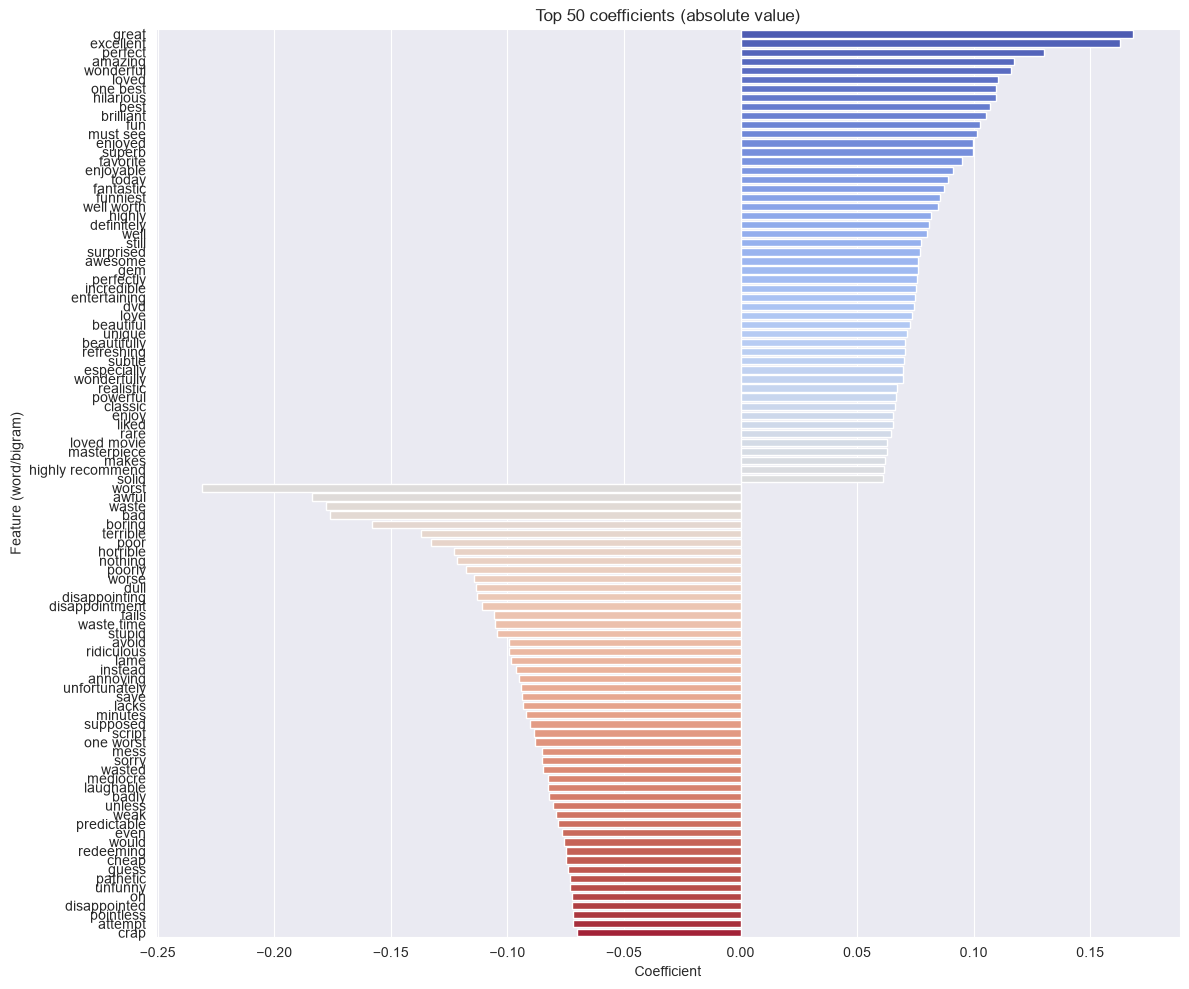

Top 10 positive:
          feature      coef
52310       great  0.168537
37553   excellent  0.162908
91302     perfect  0.130012
4675      amazing  0.117381
137396  wonderful  0.116076
71709       loved  0.110456
86851    one best  0.109785
56018   hilarious  0.109773
11353        best  0.107029
14701   brilliant  0.105418

Top 10 negative:
         feature      coef
138345     worst -0.230860
8456       awful -0.183944
133388     waste -0.177792
9001         bad -0.175953
13875     boring -0.158286
122264  terrible -0.137198
94610       poor -0.132985
57101   horrible -0.122917
85261    nothing -0.121670
94708     poorly -0.117787


In [19]:
# Визуализация коэффициентов
coef = best_lr.coef_.flatten()
feature_names = tfidf.get_feature_names_out()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})

top_positive = coef_df.nlargest(50, 'coef')
top_negative = coef_df.nsmallest(50, 'coef')
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 10))
sns.barplot(x='coef', y='feature', data=top_features, palette='coolwarm')
plt.title('Top 50 coefficients (absolute value)')
plt.xlabel('Coefficient')
plt.ylabel('Feature (word/bigram)')
plt.tight_layout()
plt.show()

print("Top 10 positive:")
print(top_positive.head(10))
print("\nTop 10 negative:")
print(top_negative.head(10))